# Demo of SED and photometry calculations with DSPS

author: Luca Tortorelli

last run successfully: May 10, 2024

This notebook demonstrates some basic usage of the rail_dsps library. In particular, for a galaxy with some arbitrary star formation history, we'll see how to calculate its restframe SED, and its absolute and apparent magnitude in some band.

SPS calculations are based on a set of template SEDs of simple stellar populations (SSPs). Supplying such templates is outside the planned scope of the DSPS package, and so they will need to be retrieved from some other library. For example, the FSPS library supplies such templates in a convenient form.

In case the user is not aware of how to generate these templates, the code automatically downloads a pre-defined library from NERSC.

**Note:** If you're planning to run this in a notebook, you may want to use interactive mode instead. See [DSPS_SED.ipynb](https://github.com/LSSTDESC/rail/blob/main/interactive_examples/creation_examples/DSPS_SED.ipynb) in the `interactive_examples/creation_examples/` folder for a version of this notebook in interactive mode.

### SingleSedModeler

The SingleSedModeler class allows the user to generate a single rest-frame SED at the time with rail_dsps.

Some example galaxy properties that are required to create a single SED model are generated via this notebook and stored into an hdf5 table. The required galaxy properties are:

- galaxy redshifts
- the grid of cosmic time over which the star-formation history of galaxies is evaluated in units of Gyr
- the star-formation history of galaxies in units of Msun/yr
- galaxy metallicity at the time of observation in units of log10(Z)
- log normal scatter of the galaxy metallicity at the time of observation


In [1]:
import os
import rail.dsps
from rail.core.stage import RailStage
from rail.core.data import Hdf5Handle
import numpy as np
import h5py

In [2]:
# DS = RailStage.data_store
# DS.__class__.allow_overwrite = True

RAIL_DSPS_DIR = os.path.abspath(os.path.join(os.path.dirname(rail.dsps.__file__), '..'))
default_rail_fsps_files_folder = os.path.join(RAIL_DSPS_DIR, 'examples_data/creation_data/data/dsps_default_data')
trainFile = os.path.join(default_rail_fsps_files_folder, 'input_galaxy_properties_dsps.hdf5')

In [3]:
n_galaxies = 100

redshift = np.linspace(0.1,1.0,num=n_galaxies)

gal_t_table = np.linspace(0.05, 13.8, 100) # age of the universe in Gyr
gal_sfr_table = np.random.uniform(0, 10, gal_t_table.size) # SFR in Msun/yr

gal_lgmet = -2.0 # log10(Z)
gal_lgmet_scatter = 0.2 # lognormal scatter in the metallicity distribution function

cosmic_time_grid = np.full((n_galaxies, len(gal_t_table)), gal_t_table)
star_formation_history = np.full((n_galaxies, len(gal_sfr_table)), gal_sfr_table)
stellar_metallicity = np.full(n_galaxies, gal_lgmet)
stellar_metallicity_scatter = np.full(n_galaxies, gal_lgmet_scatter)

with h5py.File(trainFile, 'w') as h5table:
    h5table.create_dataset(name='redshifts', data=redshift)
    h5table.create_dataset(name='cosmic_time_grid', data=cosmic_time_grid)
    h5table.create_dataset(name='star_formation_history', data=star_formation_history)
    h5table.create_dataset(name='stellar_metallicity', data=stellar_metallicity)
    h5table.create_dataset(name='stellar_metallicity_scatter', data=stellar_metallicity_scatter)

In [4]:
# training_data = DS.read_file("training_data", Hdf5Handle, trainFile)
training_data = Hdf5Handle("training_data",path=trainFile)

The user is also required to provide the template SSPs with which rail_dsps generates its rest-frame SEDs. Leaving it blank or to a non-existing file will lead rail_dsps to generate the default templates from NERSC.

In [5]:
dspssinglesedmodeler = rail.dsps.DSPSSingleSedModeler.make_stage(name='DSPSSingleSedModeler',
                                                                 #ssp_templates_file=os.path.join(RAIL_DSPS_DIR,'examples_data/creation_data/data/dsps_default_data/ssp_data_fsps_v3.2_lgmet_age.h5'),
                                                                 ssp_templates_file='/pscratch/sd/q/qhang/dsps_ssp/ssp_mist_c3k_a_chabrier_wNE_logGasU-2.0_logGasZ0.0.h5',
                                                                 edshift_key='redshifts',
                                                                 cosmic_time_grid_key='cosmic_time_grid',
                                                                 star_formation_history_key='star_formation_history',
                                                                 stellar_metallicity_key='stellar_metallicity',
                                                                 stellar_metallicity_scatter_key='stellar_metallicity_scatter',
                                                                 restframe_sed_key='restframe_seds', default_cosmology=True,
                                                                 min_wavelength=250, max_wavelength=12000)

In [6]:
dspssinglesedmodel = dspssinglesedmodeler.fit_model(input_data=training_data)

Inserting handle into data store.  training_data: None, DSPSSingleSedModeler
Inserting handle into data store.  model_DSPSSingleSedModeler: inprogress_model_DSPSSingleSedModeler.hdf5, DSPSSingleSedModeler


In [7]:
dspssinglesedmodel.data

{'restframe_seds': array([[3.43180195e-09, 3.50604612e-09, 3.71217723e-09, ...,
         1.01574195e-04, 1.00043886e-04, 1.00912090e-04],
        [3.43946271e-09, 3.51315377e-09, 3.71799080e-09, ...,
         1.07213898e-04, 1.05610496e-04, 1.06518848e-04],
        [3.45585471e-09, 3.52911744e-09, 3.73384079e-09, ...,
         1.08101733e-04, 1.06485335e-04, 1.07390828e-04],
        ...,
        [2.11536033e-09, 2.15130069e-09, 2.26179075e-09, ...,
         6.89367516e-05, 6.79292789e-05, 6.84468396e-05],
        [2.12326734e-09, 2.15865659e-09, 2.26903007e-09, ...,
         7.07071231e-05, 6.96743227e-05, 7.02068937e-05],
        [2.10976059e-09, 2.14475460e-09, 2.25396035e-09, ...,
         7.59300456e-05, 7.48323073e-05, 7.54116045e-05]], dtype=float32),
 'redshifts': array([0.1       , 0.10909091, 0.11818182, 0.12727273, 0.13636364,
        0.14545455, 0.15454545, 0.16363636, 0.17272727, 0.18181818,
        0.19090909, 0.2       , 0.20909091, 0.21818182, 0.22727273,
        0.23636

In [10]:
dspssinglesedmodel.data['restframe_seds'].shape

(100, 9163)

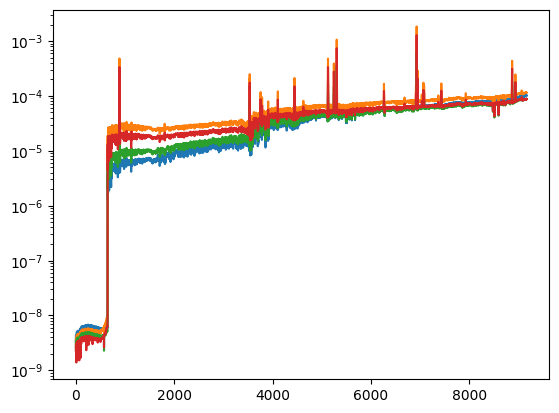

In [22]:
import matplotlib.pyplot as plt
for i in [0,25,50,75]:
    plt.plot(dspssinglesedmodel.data['restframe_seds'][i,:])
plt.yscale('log')

### PopulationSedModeler

The PopulationSedModeler class works in a similar way as the SingleSedModeler class, but allows the user to generate a population of rest-frame SEDs using the native parallelization capabilities of jax.


In [23]:
import os
import rail.dsps
from rail.core.stage import RailStage
from rail.core.data import Hdf5Handle
import numpy as np
import h5py

In [24]:
default_rail_fsps_files_folder = os.path.join(RAIL_DSPS_DIR, 'examples_data/creation_data/data/dsps_default_data')
trainFile = os.path.join(default_rail_fsps_files_folder, 'input_galaxy_properties_dsps.hdf5')

SFR from Ciesla + 2015 (https://arxiv.org/pdf/2409.19066)

In [1]:
def get_sfr_delayed_tau(t, tau_main):
    #tau_main = [0.1, 0.5, 1, 3, 5, 8]
    #t_main = [0.5, 1, 3, 4.5, 6, 8, 10, 13]
    #f_ySP = [0, 0.01, 0.1, 0.2]
    # k depends on f_ySP, A is a normalization for sfr_delayed
    tau_burst = 10
    t_burst = 0.05
    sfr_delayed = t/tau_main**2 * np.exp(-t/tau_main) * A
    if t < t_main - t_burst:
        sfr_burst = 0
    else:
        sfr_burst = k*np.exp(-(t - (t_main - t_burst))/tau_burst)
    return sfr_delayed + sfr_burst

In [25]:
n_galaxies = 100

redshift = np.linspace(0.1,1.0,num=n_galaxies)

gal_t_table = np.linspace(0.05, 13.8, 100) # age of the universe in Gyr
gal_sfr_table = np.random.uniform(0, 10, gal_t_table.size) # SFR in Msun/yr

gal_lgmet = -2.0 # log10(Z)
gal_lgmet_scatter = 0.2 # lognormal scatter in the metallicity distribution function

cosmic_time_grid = np.full((n_galaxies, len(gal_t_table)), gal_t_table)
star_formation_history = np.full((n_galaxies, len(gal_sfr_table)), gal_sfr_table)
stellar_metallicity = np.full(n_galaxies, gal_lgmet)
stellar_metallicity_scatter = np.full(n_galaxies, gal_lgmet_scatter)

with h5py.File(trainFile, 'w') as h5table:
    h5table.create_dataset(name='redshifts', data=redshift)
    h5table.create_dataset(name='cosmic_time_grid', data=cosmic_time_grid)
    h5table.create_dataset(name='star_formation_history', data=star_formation_history)
    h5table.create_dataset(name='stellar_metallicity', data=stellar_metallicity)
    h5table.create_dataset(name='stellar_metallicity_scatter', data=stellar_metallicity_scatter)

In [26]:
training_data = Hdf5Handle("training_data",path=trainFile)

In [30]:
dspspopulationsedmodeler = rail.dsps.DSPSPopulationSedModeler.make_stage(name='DSPSPopulationSedModeler',
                                                                         #ssp_templates_file=os.path.join(RAIL_DSPS_DIR,
                                                                         #'examples_data/creation_data/data/dsps_default_data/ssp_data_fsps_v3.2_lgmet_age.h5'),
                                                                         ssp_templates_file='/pscratch/sd/q/qhang/dsps_ssp/ssp_mist_c3k_a_chabrier_wNE_logGasU-2.0_logGasZ0.0.h5',
                                                                         redshift_key='redshifts',
                                                                         cosmic_time_grid_key='cosmic_time_grid',
                                                                         star_formation_history_key='star_formation_history',
                                                                         stellar_metallicity_key='stellar_metallicity',
                                                                         stellar_metallicity_scatter_key='stellar_metallicity_scatter',
                                                                         restframe_sed_key='restframe_seds', default_cosmology=True,
                                                                         min_wavelength=250, max_wavelength=12000)

In [31]:
dspspopulationsedmodel = dspspopulationsedmodeler.fit_model(input_data=training_data)

Inserting handle into data store.  training_data: None, DSPSPopulationSedModeler
Inserting handle into data store.  model_DSPSPopulationSedModeler: inprogress_model_DSPSPopulationSedModeler.hdf5, DSPSPopulationSedModeler


In [32]:
dspspopulationsedmodel.data

{'restframe_seds': Array([[3.25519145e-09, 3.32264150e-09, 3.51321261e-09, ...,
         1.17958058e-04, 1.16235329e-04, 1.17225492e-04],
        [3.23070970e-09, 3.29806316e-09, 3.48781803e-09, ...,
         1.12644782e-04, 1.10991990e-04, 1.11938032e-04],
        [3.23177507e-09, 3.29902350e-09, 3.48857476e-09, ...,
         1.09999564e-04, 1.08379703e-04, 1.09302040e-04],
        ...,
        [2.40237297e-09, 2.44100584e-09, 2.56920263e-09, ...,
         8.74065008e-05, 8.61391891e-05, 8.68057832e-05],
        [2.38621589e-09, 2.42489606e-09, 2.55269494e-09, ...,
         8.60868895e-05, 8.48381023e-05, 8.54939499e-05],
        [2.35242537e-09, 2.39100784e-09, 2.51706700e-09, ...,
         8.35110477e-05, 8.22956281e-05, 8.29292694e-05]], dtype=float32),
 'redshifts': array([0.1       , 0.10909091, 0.11818182, 0.12727273, 0.13636364,
        0.14545455, 0.15454545, 0.16363636, 0.17272727, 0.18181818,
        0.19090909, 0.2       , 0.20909091, 0.21818182, 0.22727273,
        0.23636

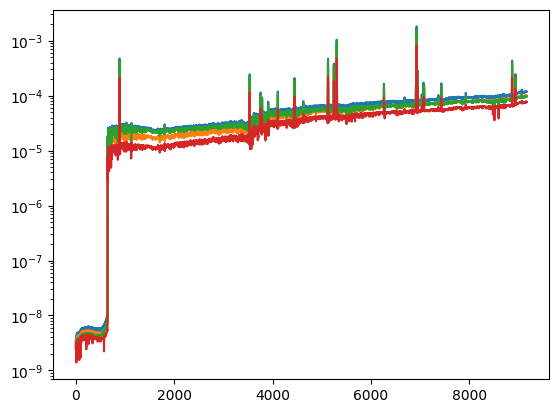

In [33]:
import matplotlib.pyplot as plt
for i in [0,25,50,75]:
    plt.plot(dspspopulationsedmodel.data['restframe_seds'][i,:])
plt.yscale('log')
#plt.xlim([4400,4600])

### DSPSPhotometryCreator

This class allows the user to generate model photometry by computing the absolute and apparent magnitudes of galaxies from their input rest-frame SEDs. Although DSPSPopulationSedModeler generates the rest-frame SEDs that are needed for this class, the user can supply whatever external SED provided that the units are in Lsun/Hz.

Generating the observed photometry with DSPS is simple and requires only few input from the user. The required input are:
- the redshift dataset keyword of the hdf5 table containing the rest-frame SEDs output from the DSPSPopulationSedModeler
- the rest-frame SEDs dataset keyword of the hdf5 table containing the rest-frame SEDs output from the DSPSPopulationSedModeler
- the absolute and apparent magnitudes dataset keyword of the output hdf5 table
- the folder path containing the filter bands
- the name of the filter bands in order of increasing wavelength
- the minimum and maximum wavelength used in the DSPSPopulationSedModeler class to generate the rest-frame SEDs
- the path to the SSP template files
- a boolean keyword to use (True) the default cosmology in DSPS.

If the latter keyword is set to False, then the user has to manually provide the values of Om0, w0, wa and h in the .sample function.

In [34]:
import os
import rail.dsps
from rail.core.stage import RailStage
from rail.core.data import Hdf5Handle

In [35]:
trainFile = 'model_DSPSPopulationSedModeler.hdf5'

In [36]:
training_data = Hdf5Handle("training_data",path=trainFile)

In [38]:
dspsphotometrycreator = rail.dsps.DSPSPhotometryCreator.make_stage(name='DSPSPhotometryCreator',
                                                         redshift_key='redshifts',
                                                         restframe_sed_key='restframe_seds',
                                                         absolute_mags_key='rest_frame_absolute_mags',
                                                         apparent_mags_key='apparent_mags',
                                                         filter_folder=os.path.join(RAIL_DSPS_DIR,
                                                         'examples_data/creation_data/data/dsps_default_data/filters'),
                                                         instrument_name='lsst',
                                                         wavebands='u,g,r,i,z,y',
                                                         min_wavelength=250, max_wavelength=12000,
                                                         #ssp_templates_file=os.path.join(RAIL_DSPS_DIR,
                                                         #'examples_data/creation_data/data/dsps_default_data/ssp_data_fsps_v3.2_lgmet_age.h5'),
                                                         ssp_templates_file='/pscratch/sd/q/qhang/dsps_ssp/ssp_mist_c3k_a_chabrier_wNE_logGasU-2.0_logGasZ0.0.h5',
                                                         default_cosmology=True)

{output_mode:default,redshift_key:redshifts,restframe_sed_key:restframe_seds,absolute_mags_key:rest_frame_absolute_mags,apparent_mags_key:apparent_mags,filter_folder:/global/u2/q/qhang/desc/rail_dsps/src/rail/examples_data/creation_data/data/dsps_default_data/filters,instrument_name:lsst,wavebands:u,g,r,i,z,y,min_wavelength:250.0,max_wavelength:12000.0,ssp_templates_file:/pscratch/sd/q/qhang/dsps_ssp/ssp_mist_c3k_a_chabrier_wNE_logGasU-2.0_logGasZ0.0.h5,default_cosmology:True,name:DSPSPhotometryCreator,config:None,model:None,}


In [41]:
dspsphotometry = dspsphotometrycreator.sample(input_data=training_data, model=dspspopulationsedmodel)

Inserting handle into data store.  model_DSPSPopulationSedModeler: None, DSPSPhotometryCreator
Inserting handle into data store.  output_DSPSPhotometryCreator: inprogress_output_DSPSPhotometryCreator.hdf5, DSPSPhotometryCreator


In [43]:
(dspsphotometry.data).keys()

dict_keys(['id', 'rest_frame_absolute_mags', 'apparent_mags'])

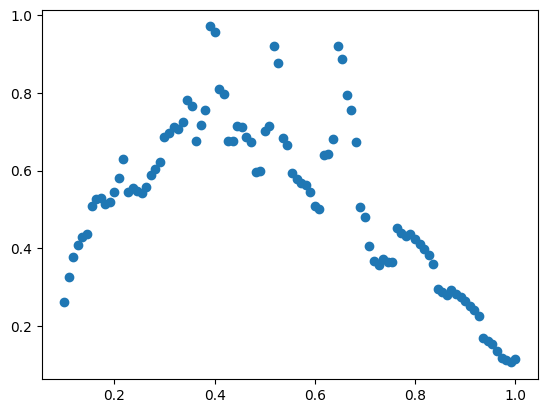

In [48]:
g = dspsphotometry.data['apparent_mags'][:,1]
r = dspsphotometry.data['apparent_mags'][:,2]
i = dspsphotometry.data['apparent_mags'][:,3]
gr=g-r
ri = r-i
plt.scatter(redshift, gr)

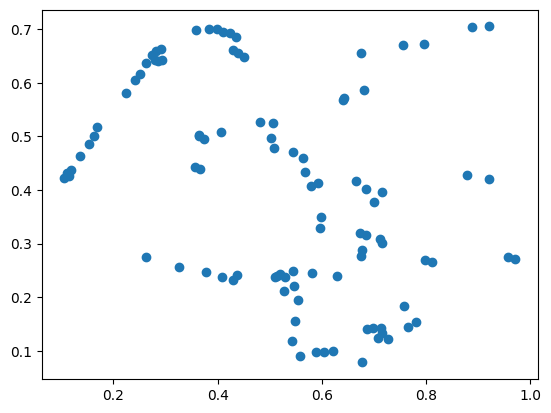

In [49]:
plt.scatter(gr, ri)